## **Importação dos dados**

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## **Limpeza e tratamento**

In [49]:
# apagando nulos
df = df.dropna(subset=['Age'])
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [50]:
# convertendo idade para int
df['Age'] = df['Age'].astype(int)
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,int64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


## **Vizualização dos dado**

In [15]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000
mean,448.582633,0.406162,2.236695,29.679272,0.512605,0.431373,34.694514
std,259.119524,0.491460,0.838250,14.536483,0.929783,0.853289,52.918930
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,222.250000,0.000000,1.000000,20.000000,0.000000,0.000000,8.050000
50%,445.000000,0.000000,2.000000,28.000000,0.000000,0.000000,15.741700
75%,677.750000,1.000000,3.000000,38.000000,1.000000,1.000000,33.375000
max,891.000000,1.000000,3.000000,80.000000,5.000000,6.000000,512.329200


In [52]:
# taxa de sobrevivência geral
taxa_geral = df['Survived'].mean() * 100
print(f"Taxa de sobrevivência geral: {taxa_geral:.2f}%")

Taxa de sobrevivência geral: 40.62%


In [78]:
# sobrevivência por sexo
sobrevivencia_sexo = df.groupby('Sex')['Survived'].mean() * 100
print(sobrevivencia_sexo)

Sex
female    75.478927
male      20.529801
Name: Survived, dtype: float64


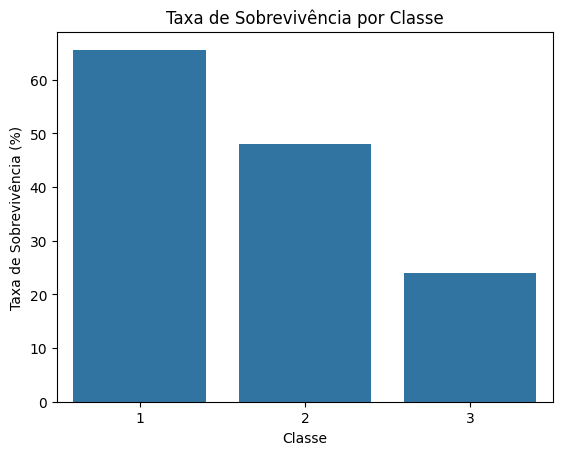

In [61]:
# sobrevivência por classe
taxa_classe = df.groupby('Pclass')['Survived'].mean()

sns.barplot(x=taxa_classe.index, y=taxa_classe.values * 100)
plt.title('Taxa de Sobrevivência por Classe')
plt.xlabel('Classe')
plt.ylabel('Taxa de Sobrevivência (%)')
plt.show()

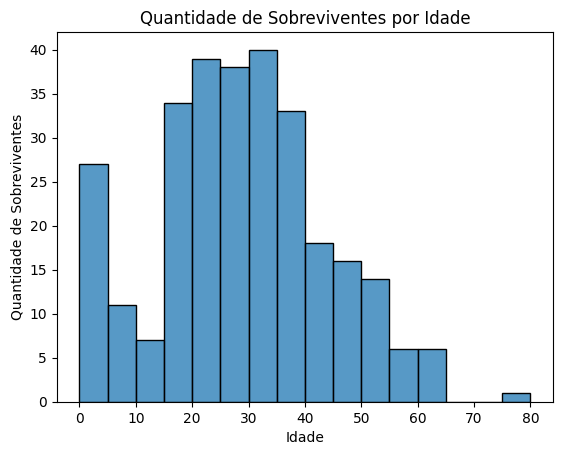

In [66]:
# Quantidade de sobreviventes por idade
sns.histplot(data=df[df['Survived'] == 1], x='Age')
plt.title('Quantidade de Sobreviventes por Idade')
plt.xlabel('Idade')
plt.ylabel('Quantidade de Sobreviventes')
plt.show()



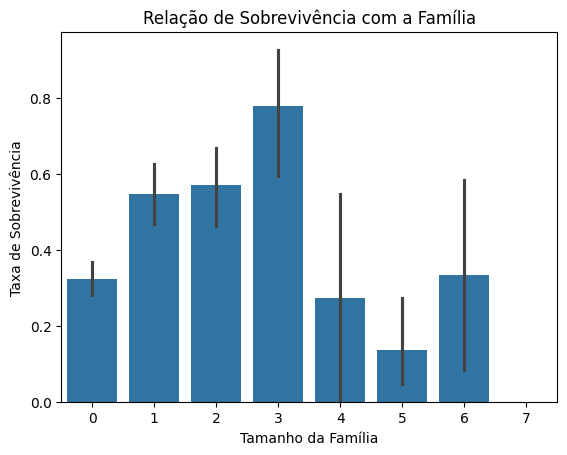

In [69]:
# relação de sobrevivência com a família
df['FamilySize'] = df['SibSp'] + df['Parch']

sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title('Relação de Sobrevivência com a Família')
plt.xlabel('Tamanho da Família')
plt.ylabel('Taxa de Sobrevivência')
plt.show()

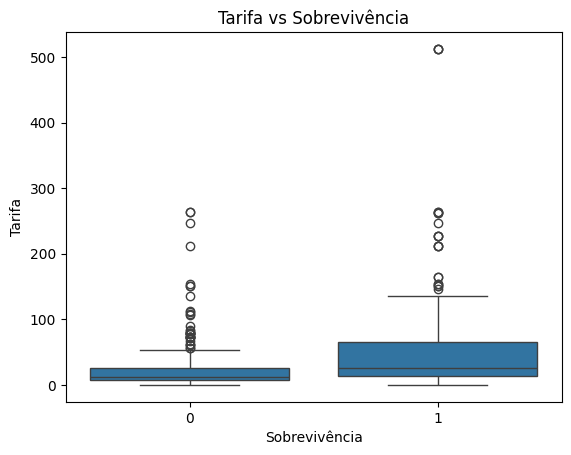

In [75]:
# relação de sobrevivência com valor pago na tarifa
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Tarifa vs Sobrevivência')
plt.xlabel('Sobrevivência')
plt.ylabel('Tarifa')
plt.show()

*mediana de quem sobreviveu é maior → dinheiro influencia*

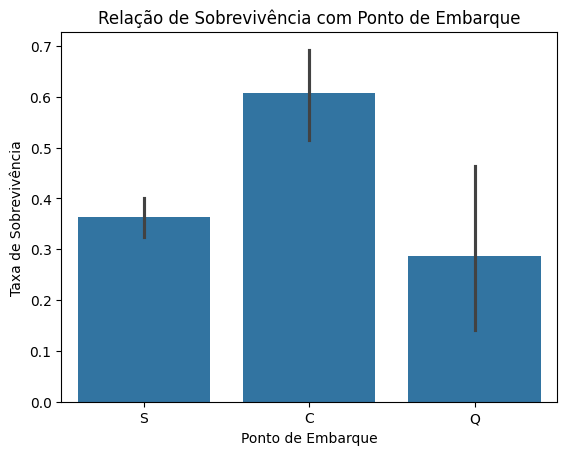

In [76]:
# relação de sobrevivência com ponto de embarque
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title('Relação de Sobrevivência com Ponto de Embarque')
plt.xlabel('Ponto de Embarque')
plt.ylabel('Taxa de Sobrevivência')
plt.show()

*diferentes pontos de embarque = diferentes classes sociais*